In [2]:
import os

import anndata
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from Bio import Phylo
import scgenome.plotting as pl

from cellmates.common_helpers.cnasim_data import profiles_to_anndata


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# CNAsim benchmark data visualization
Visualize CNAsim datasets replicated simulations with ancestral CN profiles and readcounts with same params as in the DICE paper published data: [zenodo link](https://zenodo.org/records/10108731)

## Defaults parameters
Each dataset shows variations of one or more parameters, all the rest are fixed to defaults parameters. Below is the list of parameters defaults:
```
defaults:
  n_cells: 250
  n_chromosomes: 22
  chromosome_length: 100
  mean_cnas_per_edge: 2
  bin_size: 1000000
  n_clones: 0
  wgd: false
  boundary_noise: 0
  jitter: 0
```

In [3]:
dat_path = "/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results"

## A datasets

| Dataset | Number of cells |
|---------|-----------------|
| A1      | 10              |
| A2      | 25              |
| A3      | 50              |
| A4      | 75              |
| A5      | 100             |
| A6      | 250             |
| A7      | 500             |

In [4]:
test_dat = os.path.join(dat_path, "A2_0", "5")
tree_nwk_path = os.path.join(test_dat, "tree.nwk")
test_tree_bio = Phylo.read(tree_nwk_path,'newick')
test_adata = anndata.read_h5ad(os.path.join(test_dat, "anndata.h5ad"))
test_adata

AnnData object with n_obs × n_vars = 25 × 2879
    obs: 'normal', 'clone'
    var: 'chr', 'start', 'end'
    uns: 'ancestral-cn', 'ancestral-cnA', 'ancestral-cnB', 'ancestral-names', 'cell-tree-newick', 'clonal-tree-newick', 'clone-id-tree-newick', 'cnasim-params'
    layers: 'Acopy', 'Acount', 'Astate', 'Bcopy', 'Bcount', 'Bstate', 'copy', 'state'

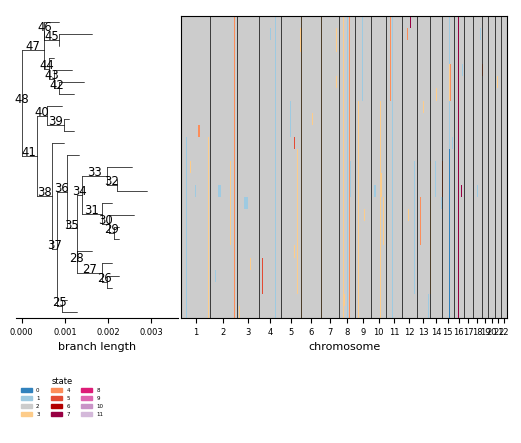

In [5]:
from io import StringIO
from cellmates.utils.tree_utils import make_gt_tree_dist

# use tree from cn-derived branch lengths
dpy_tree, gt_ctr = make_gt_tree_dist(test_adata, n_states=7, cell_names=test_adata.obs_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = test_adata.obs_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick', )
g = pl.plot_cell_cn_matrix_fig(test_adata, layer_name='state', tree=bio_tree_cn_lengths)

### Readcounts and ancestral cn sequences

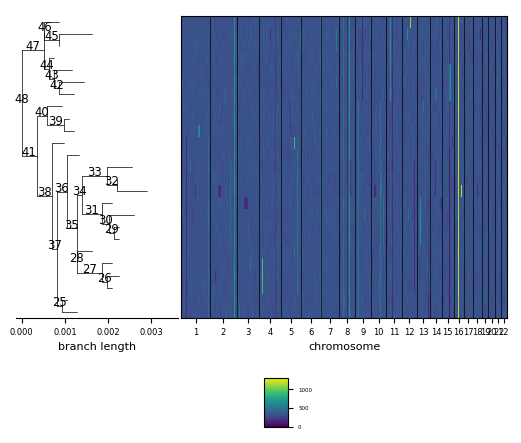

In [6]:
g = pl.plot_cell_cn_matrix_fig(test_adata, layer_name=None, tree=bio_tree_cn_lengths, raw=True)

In [7]:
test_adata.uns['ancestral-cn'].shape

(24, 2879)

In [8]:
test_adata.uns['ancestral-names'].shape # reference to tree names

(24,)

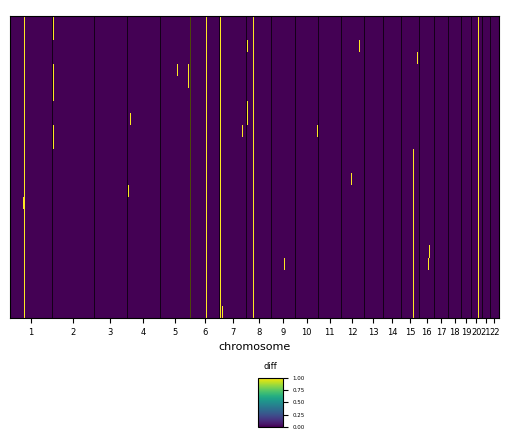

In [9]:
# breakpoint checks
test_adata.layers['diff'] = np.diff(test_adata.layers['state'], append=0) > 0
g = pl.plot_cell_cn_matrix_fig(test_adata, layer_name='diff', raw=True)

In [10]:
test_adata.layers['diff'].sum(axis=1)

array([27, 26, 28, 28, 33, 27, 30, 29, 30, 32, 30, 32, 29, 31, 34, 41, 37,
       38, 38, 44, 41, 39, 38, 37, 37])

#### Readcounts too high investigation

Coverage is 0.1 and total number of sites matches the size of human genome

In [23]:
# check that total sequence length matches hg38 genome
tot_sites =np.sum(test_adata.var.groupby(by='chr', observed=False).max()['end'].values)
print(f"Coverage: {test_adata.uns['cnasim-params']['coverage']}, total sites: {tot_sites/10**9:.2f}Gb (should be close to 3Gb)")
print(f"Avg bin readcount: {test_adata.X.mean()}")

Coverage: 0.1, total sites: 2.88Gb (should be close to 3Gb)
Avg bin readcount: 338.9690170197985


# Normalization through CNAsim parameters

Normal cells are not available to compute RDR, but since the parameters for the simulation are known and coverage is set to uniform, we can normalize tumor readcounts nevertheless.

We first compute the average number of reads per bin and cell
$$
\lambda = \frac{B \times C}{2R}\,,\qquad y_{mn} = X_{mn} / \lambda
$$
where $B, C, R$ are respectively the bin length (bp), sequencing coverage, and read length (bp).
We divide each read count in the tumor data by that value and we obtain a normalized readcounts where a value of ~1.0 indicates diploid (normal) count.

In [ ]:
lamda = test_adata.uns['cnasim-params']['bin_length'] * test_adata.uns['cnasim-params']['coverage'] / test_adata.uns['cnasim-params']['read_length'] / 2
test_adata.layers['rdr'] = test_adata.X / lamda
test_adata.layers['copy'] = test_adata.layers['rdr'] * 2
g = pl.plot_cell_cn_matrix_fig(test_adata, layer_name='rdr', raw=True)

This normalization is such that pretty much none of the normalized readcounts are distant from their GT cn more than 0.5 (as shown in the plot below)

In [ ]:
norm_err = test_adata.layers['copy'] - test_adata.layers['state']
# plot err to see if it fits a gaussian
g = plt.hist(norm_err.flatten(), bins=100)

In [ ]:
test_adata.uns['cnasim-params']